# Enhanced Ramping Risk Analysis

**Purpose:** Quantify grid ramping risk under high renewable penetration with focus on:
1. Sunset ramping window (17-20h) critical period analysis
2. Nonlinear threshold detection
3. Temporal clustering of extreme events
4. Operational feasibility assessment

**Data Requirements:**
- `hourly_load_renewable_merged.csv` (from notebook 01)
- Sensitivity results from notebook 03 (or regenerate)

**Key Hypothesis:** Ramping risk scales nonlinearly with renewable penetration, with critical threshold around 45-50% instantaneous penetration.

In [1]:
# Setup
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Paths
ROOT = Path('C:/Renewable-PowerGrid-Risk')
PROCESSED_DIR = ROOT / 'data' / 'processed'
FIGURES_DIR = ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Add src to path
src_path = ROOT / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from metrics import compute_risk_metrics

# Load data
df = pd.read_csv(PROCESSED_DIR / 'hourly_load_renewable_merged.csv', parse_dates=['datetime'])
print(f"Loaded {len(df):,} hourly records from {df['datetime'].min()} to {df['datetime'].max()}")

# Compute derived columns if not present
if 'ramp_1h' not in df.columns:
    df['ramp_1h'] = df['NET_LOAD'].diff()
    df['ramp_3h'] = df['NET_LOAD'].diff(3)

df.head()

Loaded 26,310 hourly records from 2023-01-01 01:00:00 to 2026-01-01 00:00:00


,datetime,Date,ERCOT.LOAD,ERCOT.WIND.GEN,"Total Wind Installed, MW","Wind Output, % of Load","Wind Output, % of Installed",Wind 1-hr MW change,Wind 1-hr % change,ERCOT.PVGR.GEN,...,Daytime Hour,Ramping Daytime Hour,hour,month,renewable,renewable_capacity,renewable_share,NET_LOAD,ramp_1h,ramp_3h
0,2023-01-01 01:00:00,2023-01-01,35829.306163,21753.284477,36858,60.713664,59.019167,NaN,NaN,0.449746,...,False,False,1,1,21753.734223,51107,0.607149,14075.571940,NaN,NaN
1,2023-01-01 02:00:00,2023-01-01,35245.390234,21570.395694,36858,61.200615,58.522968,-182.888783,-0.840741,0.454733,...,False,False,2,1,21570.850427,51107,0.612019,13674.539807,-401.032133,NaN
2,2023-01-01 03:00:00,2023-01-01,34599.761810,21036.504013,36858,60.799563,57.074459,-533.891682,-2.475113,0.443528,...,False,False,3,1,21036.947541,51107,0.608008,13562.814269,-111.725538,NaN
3,2023-01-01 04:00:00,2023-01-01,34227.151061,20595.481515,36858,60.172935,55.877914,-441.022498,-2.096463,0.458567,...,False,False,4,1,20595.940081,51107,0.601743,13631.210980,68.396710,-444.360960
4,2023-01-01 05:00:00,2023-01-01,34093.414143,20387.843555,36858,59.799947,55.314568,-207.637960,-1.008172,0.451126,...,False,False,5,1,20388.294681,51107,0.598013,13705.119462,73.908482,30.579655


## 1. CRITICAL ANALYSIS: Sunset Ramping Window (17-20h)

This is THE most important period for grid stress:
- Solar drops from peak (~25 GW) to near-zero in 3 hours
- Load remains high (evening peak)
- Wind typically LOW in Texas summer evenings
- Net load ramps can exceed 15,000 MW/hour

In [2]:
# 1.1 Create sunset-specific dataset
sunset_hours = [17, 18, 19, 20]
summer_months = [5, 6, 7, 8, 9]  # May-September most critical

df_sunset = df[
    df['hour'].isin(sunset_hours) & 
    df['month'].isin(summer_months)
].copy()

print(f"Sunset window dataset: {len(df_sunset):,} hours")
print(f"Years covered: {sorted(df_sunset['datetime'].dt.year.unique())}")

Sunset window dataset: 1,836 hours
Years covered: [2023, 2024, 2025]


In [3]:
# 1.2 Compute daily sunset ramp (17h → 20h)
# For each day, calculate the total net load change from hour 17 to hour 20

def compute_daily_sunset_ramp(df):
    """
    Compute 3-hour sunset ramp for each day.
    Returns: DataFrame with date, sunset_ramp_3h, and related metrics
    """
    daily_sunset = []
    
    for date, day_df in df.groupby(df['datetime'].dt.date):
        day_df = day_df.sort_values('hour')
        
        # Need all 4 hours present
        if len(day_df) != 4 or not all(h in day_df['hour'].values for h in sunset_hours):
            continue
        
        # Get NET_LOAD at hour 17 and hour 20
        nl_17 = day_df[day_df['hour']==17]['NET_LOAD'].values[0]
        nl_20 = day_df[day_df['hour']==20]['NET_LOAD'].values[0]
        
        # Solar and wind context
        solar_drop = (day_df[day_df['hour']==17]['ERCOT.PVGR.GEN'].values[0] - 
                     day_df[day_df['hour']==20]['ERCOT.PVGR.GEN'].values[0])
        
        wind_avg = day_df['ERCOT.WIND.GEN'].mean()
        load_avg = day_df['ERCOT.LOAD'].mean()
        
        daily_sunset.append({
            'date': date,
            'sunset_ramp_3h': nl_20 - nl_17,
            'solar_drop_MW': solar_drop,
            'wind_avg_MW': wind_avg,
            'load_avg_MW': load_avg,
            'peak_solar_penetration': day_df['ERCOT.PVGR.GEN'].max() / load_avg,
        })
    
    return pd.DataFrame(daily_sunset)

daily_sunset = compute_daily_sunset_ramp(df_sunset)
print(f"\nDaily sunset ramp statistics (May-Sep, 2023-2025):")
print(daily_sunset['sunset_ramp_3h'].describe().round(0))

# Display worst sunset ramping days
print("\n10 Worst Sunset Ramping Days:")
display(daily_sunset.nlargest(10, 'sunset_ramp_3h')[[
    'date', 'sunset_ramp_3h', 'solar_drop_MW', 'wind_avg_MW', 'peak_solar_penetration'
]].round(0))


Daily sunset ramp statistics (May-Sep, 2023-2025):
count      459.0
mean      5446.0
std       5068.0
min      -8502.0
25%       1846.0
50%       4437.0
75%       8919.0
max      19421.0
Name: sunset_ramp_3h, dtype: float64

10 Worst Sunset Ramping Days:


,date,sunset_ramp_3h,solar_drop_MW,wind_avg_MW,peak_solar_penetration
432,2025-09-04,19421.0,25416.0,7132.0,0.0
436,2025-09-08,19066.0,24797.0,8634.0,0.0
430,2025-09-02,18756.0,21316.0,6636.0,0.0
431,2025-09-03,18493.0,23417.0,2658.0,0.0
316,2025-05-11,18082.0,16234.0,4947.0,0.0
453,2025-09-25,17915.0,22396.0,1917.0,0.0
438,2025-09-10,17671.0,25550.0,14622.0,0.0
308,2025-05-03,16983.0,19587.0,5813.0,0.0
312,2025-05-07,16115.0,18104.0,6429.0,0.0
283,2024-09-08,16046.0,19010.0,8005.0,0.0


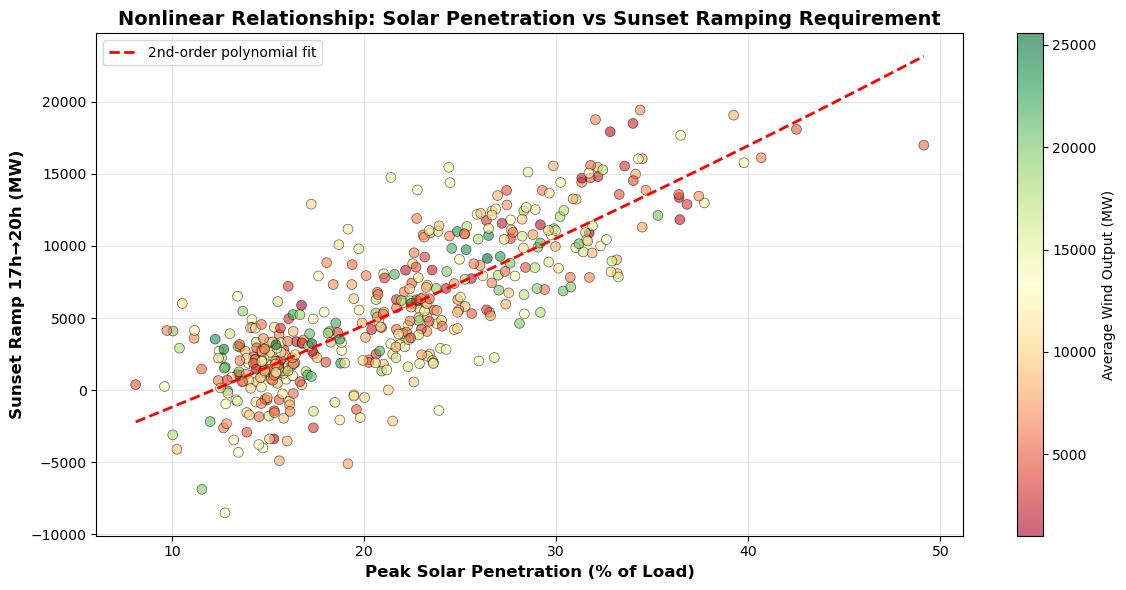


Polynomial coefficients (ax² + bx + c):
a = 18959.85, b = 50924.00, c = -6445.69

Interpretation: NONLINEAR (a>0) relationship


In [4]:
# 1.3 KEY PLOT: Solar Penetration vs Sunset Ramp (Nonlinearity Test)
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot colored by wind availability
scatter = ax.scatter(
    daily_sunset['peak_solar_penetration'] * 100,
    daily_sunset['sunset_ramp_3h'],
    c=daily_sunset['wind_avg_MW'],
    cmap='RdYlGn',
    s=50,
    alpha=0.6,
    edgecolors='black',
    linewidths=0.5
)

# Add trend line
z = np.polyfit(daily_sunset['peak_solar_penetration'], daily_sunset['sunset_ramp_3h'], 2)
p = np.poly1d(z)
x_trend = np.linspace(daily_sunset['peak_solar_penetration'].min(), 
                     daily_sunset['peak_solar_penetration'].max(), 100)
ax.plot(x_trend * 100, p(x_trend), 'r--', linewidth=2, label='2nd-order polynomial fit')

ax.set_xlabel('Peak Solar Penetration (% of Load)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sunset Ramp 17h→20h (MW)', fontsize=12, fontweight='bold')
ax.set_title('Nonlinear Relationship: Solar Penetration vs Sunset Ramping Requirement', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average Wind Output (MW)', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sunset_ramp_vs_solar_penetration.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPolynomial coefficients (ax² + bx + c):")
print(f"a = {z[0]:.2f}, b = {z[1]:.2f}, c = {z[2]:.2f}")
print(f"\nInterpretation: {'NONLINEAR (a>0)' if z[0] > 0 else 'LINEAR'} relationship")

## 2. Scenario Analysis: High Penetration Impact on Sunset Ramps

Apply multipliers to solar/wind and quantify impact on sunset ramping specifically.

In [5]:
# 2.1 Generate high penetration scenarios focused on 2025 data
df_2025 = df[df['datetime'].dt.year == 2025].copy()

scenarios = [
    {'name': 'baseline', 'solar_mult': 1.0, 'wind_mult': 1.0},
    {'name': '1.5x_solar', 'solar_mult': 1.5, 'wind_mult': 1.0},
    {'name': '2.0x_solar', 'solar_mult': 2.0, 'wind_mult': 1.0},
    {'name': '2.5x_solar', 'solar_mult': 2.5, 'wind_mult': 1.0},
]

sunset_risk_by_scenario = []

for scenario in scenarios:
    # Apply multipliers
    scenario_df = df_2025.copy()
    scenario_df['ERCOT.PVGR.GEN'] = scenario_df['ERCOT.PVGR.GEN'] * scenario['solar_mult']
    scenario_df['ERCOT.WIND.GEN'] = scenario_df['ERCOT.WIND.GEN'] * scenario['wind_mult']
    scenario_df['NET_LOAD'] = (scenario_df['ERCOT.LOAD'] - 
                               scenario_df['ERCOT.PVGR.GEN'] - 
                               scenario_df['ERCOT.WIND.GEN'])
    
    # Focus on sunset window
    scenario_sunset = scenario_df[
        scenario_df['hour'].isin(sunset_hours) & 
        scenario_df['month'].isin(summer_months)
    ].copy()
    
    # Compute sunset ramps
    daily_sunset_scenario = compute_daily_sunset_ramp(scenario_sunset)
    
    # Risk metrics
    sunset_risk_by_scenario.append({
        'scenario': scenario['name'],
        'solar_mult': scenario['solar_mult'],
        'max_sunset_ramp': daily_sunset_scenario['sunset_ramp_3h'].max(),
        'p95_sunset_ramp': daily_sunset_scenario['sunset_ramp_3h'].quantile(0.95),
        'p99_sunset_ramp': daily_sunset_scenario['sunset_ramp_3h'].quantile(0.99),
        'mean_sunset_ramp': daily_sunset_scenario['sunset_ramp_3h'].mean(),
        'days_exceeding_20GW': (daily_sunset_scenario['sunset_ramp_3h'] > 20000).sum(),
        'days_exceeding_25GW': (daily_sunset_scenario['sunset_ramp_3h'] > 25000).sum(),
    })

sunset_risk_df = pd.DataFrame(sunset_risk_by_scenario)
print("\nSunset Ramping Risk by Scenario (May-Sep):")
display(sunset_risk_df.round(0))


Sunset Ramping Risk by Scenario (May-Sep):


,scenario,solar_mult,max_sunset_ramp,p95_sunset_ramp,p99_sunset_ramp,mean_sunset_ramp,days_exceeding_20GW,days_exceeding_25GW
0,baseline,1.0,19421.0,16463.0,18905.0,9927.0,0,0
1,1.5x_solar,2.0,32129.0,27861.0,30935.0,17953.0,51,19
2,2.0x_solar,2.0,44837.0,39729.0,43529.0,25978.0,122,83
3,2.5x_solar,2.0,57545.0,51063.0,56124.0,34004.0,142,129


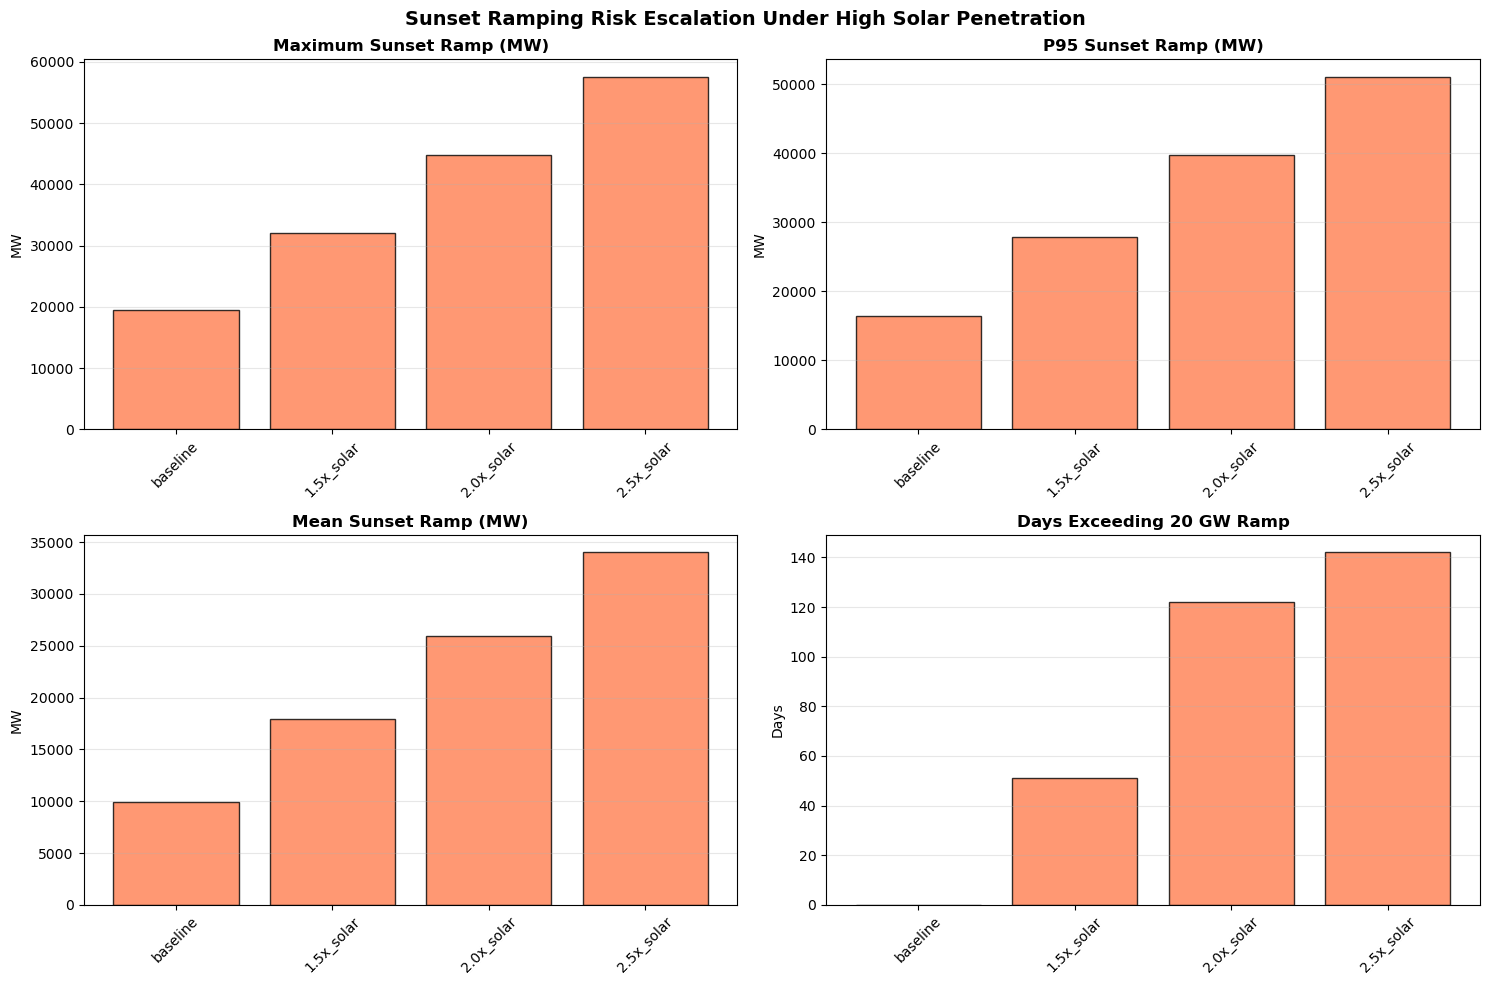

In [6]:
# 2.2 Visualize scenario comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = [
    ('max_sunset_ramp', 'Maximum Sunset Ramp (MW)'),
    ('p95_sunset_ramp', 'P95 Sunset Ramp (MW)'),
    ('mean_sunset_ramp', 'Mean Sunset Ramp (MW)'),
    ('days_exceeding_20GW', 'Days Exceeding 20 GW Ramp')
]

for idx, (metric, title) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    ax.bar(sunset_risk_df['scenario'], sunset_risk_df[metric], color='coral', alpha=0.8, edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('MW' if 'days' not in metric else 'Days')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Sunset Ramping Risk Escalation Under High Solar Penetration', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'sunset_risk_by_scenario.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Temporal Clustering Analysis

Extreme ramps don't occur independently - they cluster in multi-day periods that exhaust reserves.

In [7]:
# 3.1 Detect consecutive extreme ramp events
def compute_ramp_clustering(df, threshold_MW=6000):
    """
    Measure how often extreme ramps cluster in time.
    """
    df = df.sort_values('datetime').copy()
    
    # Mark extreme ramp hours
    df['extreme_ramp'] = df['ramp_1h'].abs() > threshold_MW
    
    # Count consecutive extreme hours
    df['ramp_streak'] = df['extreme_ramp'] * (
        df['extreme_ramp'].groupby(
            (df['extreme_ramp'] != df['extreme_ramp'].shift()).cumsum()
        ).cumcount() + 1
    )
    
    # Event statistics
    events = df[df['ramp_streak'] > 0].groupby(
        (df['ramp_streak'] == 1).cumsum()
    ).agg({
        'datetime': ['min', 'max'],
        'ramp_streak': 'max',
        'ramp_1h': lambda x: x.abs().max(),
    })
    
    events.columns = ['start_time', 'end_time', 'duration_hours', 'max_ramp']
    
    return {
        'max_consecutive_hours': df['ramp_streak'].max(),
        'p95_event_duration': events['duration_hours'].quantile(0.95),
        'mean_event_duration': events['duration_hours'].mean(),
        'num_events': len(events),
        'events_df': events,
    }

# Baseline clustering
baseline_clustering = compute_ramp_clustering(df_2025, threshold_MW=6033)
print("\nBaseline (2025) Ramp Clustering:")
print(f"  Max consecutive extreme ramp hours: {baseline_clustering['max_consecutive_hours']}")
print(f"  Mean event duration: {baseline_clustering['mean_event_duration']:.1f} hours")
print(f"  P95 event duration: {baseline_clustering['p95_event_duration']:.1f} hours")
print(f"  Total events: {baseline_clustering['num_events']}")

print("\n10 Longest Extreme Ramp Events (2025):")
display(baseline_clustering['events_df'].nlargest(10, 'duration_hours'))


Baseline (2025) Ramp Clustering:
  Max consecutive extreme ramp hours: 3
  Mean event duration: 1.4 hours
  P95 event duration: 2.0 hours
  Total events: 320

10 Longest Extreme Ramp Events (2025):


,start_time,end_time,duration_hours,max_ramp
ramp_streak,,,,
125,2025-05-20 23:00:00,2025-05-21 01:00:00,3,7013.339088
2,2025-01-01 17:00:00,2025-01-01 18:00:00,2,11670.133251
6,2025-01-06 17:00:00,2025-01-06 18:00:00,2,12383.933185
7,2025-01-07 09:00:00,2025-01-07 10:00:00,2,9466.307868
10,2025-01-11 09:00:00,2025-01-11 10:00:00,2,9152.748534
13,2025-01-13 09:00:00,2025-01-13 10:00:00,2,10452.758611
19,2025-01-16 09:00:00,2025-01-16 10:00:00,2,9423.888177
22,2025-01-19 18:00:00,2025-01-19 19:00:00,2,15862.660755
24,2025-01-21 18:00:00,2025-01-21 19:00:00,2,12976.659899


In [8]:
# 3.2 Multi-day stress window detection
def detect_multiday_stress_periods(df, days=3):
    """
    Find rolling N-day windows with highest cumulative ramping stress.
    """
    df = df.sort_values('datetime').copy()
    df['abs_ramp_1h'] = df['ramp_1h'].abs()
    
    # Rolling N-day sum of absolute ramps
    window_hours = 24 * days
    df['ramp_Nday_sum'] = df['abs_ramp_1h'].rolling(
        window=window_hours, min_periods=window_hours
    ).sum()
    
    # Find worst periods
    worst_periods = df.nlargest(20, 'ramp_Nday_sum')[[
        'datetime', 'ramp_Nday_sum', 'month', 'NET_LOAD', 'ERCOT.WIND.GEN', 'ERCOT.PVGR.GEN'
    ]].copy()
    
    worst_periods['period_label'] = worst_periods['datetime'].dt.strftime('%Y-%m-%d')
    
    return worst_periods

worst_3day_periods = detect_multiday_stress_periods(df_2025, days=3)
print(f"\n10 Worst 3-Day Ramping Stress Periods (2025):")
display(worst_3day_periods.head(10)[[
    'period_label', 'ramp_Nday_sum', 'month'
]].round(0))


10 Worst 3-Day Ramping Stress Periods (2025):


,period_label,ramp_Nday_sum,month
24159,2025-10-03,229891.0,10
24160,2025-10-03,228979.0,10
24158,2025-10-03,228943.0,10
24161,2025-10-03,227784.0,10
24157,2025-10-03,226706.0,10
24154,2025-10-03,226682.0,10
24162,2025-10-03,226475.0,10
24155,2025-10-03,226414.0,10
24156,2025-10-03,225617.0,10
24153,2025-10-03,225563.0,10


## 4. Operational Feasibility Analysis

Compare required ramps vs available dispatchable capacity.

In [9]:
# 4.1 Define ERCOT ramping capacity (2025 estimates)
# Based on ERCOT generation mix and typical ramp rates

RAMP_CAPACITY = {
    'gas_cc': 25000 * 15 / 60,      # 25 GW @ 15 MW/min = 6,250 MW/hour
    'gas_peaker': 15000 * 40 / 60,  # 15 GW @ 40 MW/min = 10,000 MW/hour  
    'battery': 5000,                 # 5 GW instantaneous
    'other': 2000,                   # Hydro, demand response
}

TOTAL_RAMP_CAPACITY = sum(RAMP_CAPACITY.values())

print(f"\nERCOT Dispatchable Ramping Capacity (2025 Estimate):")
for source, capacity in RAMP_CAPACITY.items():
    print(f"  {source:15s}: {capacity:7,.0f} MW/hour")
print(f"  {'TOTAL':15s}: {TOTAL_RAMP_CAPACITY:7,.0f} MW/hour")


ERCOT Dispatchable Ramping Capacity (2025 Estimate):
  gas_cc         :   6,250 MW/hour
  gas_peaker     :  10,000 MW/hour
  battery        :   5,000 MW/hour
  other          :   2,000 MW/hour
  TOTAL          :  23,250 MW/hour


In [10]:
# 4.2 Assess ramping adequacy by scenario
def assess_ramping_adequacy(df, scenario_name, total_capacity):
    """
    Compare required ramps vs available capacity.
    """
    df = df.copy()
    df['ramp_shortfall'] = (df['ramp_1h'].abs() - total_capacity).clip(lower=0)
    
    hours_inadequate = (df['ramp_shortfall'] > 0).sum()
    
    return {
        'scenario': scenario_name,
        'hours_exceeding_capacity': hours_inadequate,
        'pct_hours_at_risk': hours_inadequate / len(df) * 100,
        'max_shortfall_MW': df['ramp_shortfall'].max(),
        'total_shortfall_MWh': df['ramp_shortfall'].sum(),
    }

# Test each scenario
adequacy_results = []

for scenario in scenarios:
    scenario_df = df_2025.copy()
    scenario_df['ERCOT.PVGR.GEN'] = scenario_df['ERCOT.PVGR.GEN'] * scenario['solar_mult']
    scenario_df['ERCOT.WIND.GEN'] = scenario_df['ERCOT.WIND.GEN'] * scenario['wind_mult']
    scenario_df['NET_LOAD'] = (scenario_df['ERCOT.LOAD'] - 
                               scenario_df['ERCOT.PVGR.GEN'] - 
                               scenario_df['ERCOT.WIND.GEN'])
    scenario_df['ramp_1h'] = scenario_df['NET_LOAD'].diff()
    
    adequacy = assess_ramping_adequacy(scenario_df, scenario['name'], TOTAL_RAMP_CAPACITY)
    adequacy_results.append(adequacy)

adequacy_df = pd.DataFrame(adequacy_results)
print("\nRamping Adequacy Assessment:")
display(adequacy_df.round(1))


Ramping Adequacy Assessment:


,scenario,hours_exceeding_capacity,pct_hours_at_risk,max_shortfall_MW,total_shortfall_MWh
0,baseline,0,0.0,0.0,0.0
1,1.5x_solar,0,0.0,0.0,0.0
2,2.0x_solar,39,0.4,6668.0,88671.2
3,2.5x_solar,240,2.7,14777.0,872075.6


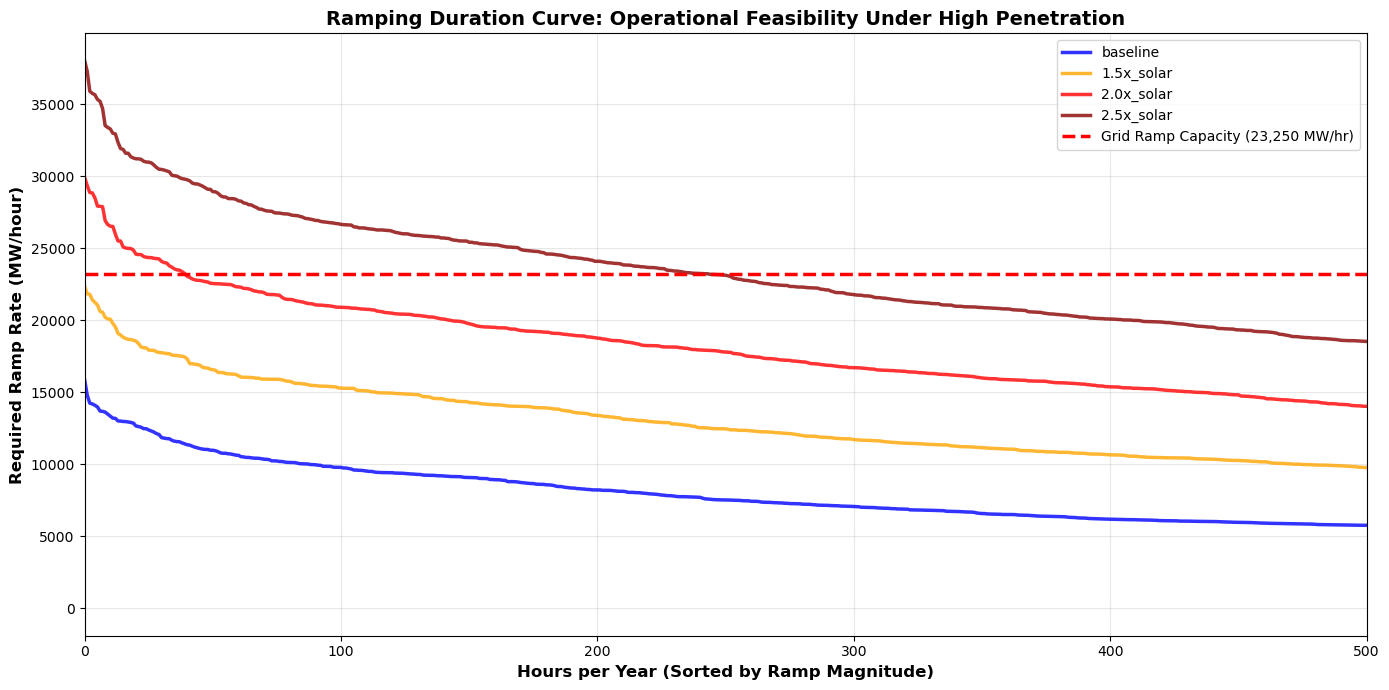

In [11]:
# 4.3 Ramping Duration Curve
fig, ax = plt.subplots(figsize=(14, 7))

colors = ['blue', 'orange', 'red', 'darkred']

for scenario, color in zip(scenarios, colors):
    scenario_df = df_2025.copy()
    scenario_df['ERCOT.PVGR.GEN'] = scenario_df['ERCOT.PVGR.GEN'] * scenario['solar_mult']
    scenario_df['ERCOT.WIND.GEN'] = scenario_df['ERCOT.WIND.GEN'] * scenario['wind_mult']
    scenario_df['NET_LOAD'] = (scenario_df['ERCOT.LOAD'] - 
                               scenario_df['ERCOT.PVGR.GEN'] - 
                               scenario_df['ERCOT.WIND.GEN'])
    scenario_df['ramp_1h'] = scenario_df['NET_LOAD'].diff()
    
    # Sort ramps descending
    ramps_sorted = scenario_df['ramp_1h'].abs().sort_values(ascending=False).values
    hours = np.arange(len(ramps_sorted))
    
    ax.plot(hours, ramps_sorted, label=scenario['name'], linewidth=2.5, color=color, alpha=0.8)

# Add capacity line
ax.axhline(y=TOTAL_RAMP_CAPACITY, color='red', linestyle='--', linewidth=2.5, 
           label=f'Grid Ramp Capacity ({TOTAL_RAMP_CAPACITY:,.0f} MW/hr)')

ax.set_xlabel('Hours per Year (Sorted by Ramp Magnitude)', fontsize=12, fontweight='bold')
ax.set_ylabel('Required Ramp Rate (MW/hour)', fontsize=12, fontweight='bold')
ax.set_title('Ramping Duration Curve: Operational Feasibility Under High Penetration', 
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 500)  # Focus on worst 500 hours
ax.grid(alpha=0.3)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ramping_duration_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## Findings Summary (Ramping Duration Curve)
The ramping duration curve provides a clear picture of how often the grid must respond to fast net-load changes, not just how large the single worst event is. On this curve, each point shows a required 1-hour ramp after all hourly ramps are sorted from largest to smallest. The high-penetration scenarios sit above the baseline for much of the left side of the plot (the most difficult hours), which means the system faces stronger ramping stress across many hours, not only at isolated peaks. In other words, renewable growth increases both the height of extreme ramps and the width of the high-risk operating window.

The dashed horizontal line marks estimated dispatchable ramping capacity. Where scenario curves rise above this line, the required balancing speed is greater than available flexible supply, creating operational shortfall risk. As solar penetration increases, these above-capacity hours become more frequent, indicating a shift from occasional stress events to repeated reliability pressure during critical periods. For the JEI Results section, the central conclusion is that grid risk depends on ramp duration as well as ramp magnitude: even if average annual conditions look manageable, repeated high-ramp hours can accumulate and overwhelm reserves unless flexibility resources (such as storage, demand response, or faster-ramping generation) expand alongside renewable penetration.

## 5. Summary Metrics Dashboard

Comprehensive comparison table for Paper 1.

In [12]:
# 5.1 Build comprehensive metrics table
summary_metrics = []

for scenario in scenarios:
    # Apply scenario
    scenario_df = df_2025.copy()
    scenario_df['ERCOT.PVGR.GEN'] = scenario_df['ERCOT.PVGR.GEN'] * scenario['solar_mult']
    scenario_df['ERCOT.WIND.GEN'] = scenario_df['ERCOT.WIND.GEN'] * scenario['wind_mult']
    scenario_df['NET_LOAD'] = (scenario_df['ERCOT.LOAD'] - 
                               scenario_df['ERCOT.PVGR.GEN'] - 
                               scenario_df['ERCOT.WIND.GEN'])
    scenario_df['ramp_1h'] = scenario_df['NET_LOAD'].diff()
    scenario_df['ramp_3h'] = scenario_df['NET_LOAD'].diff(3)
    
    # Compute all risk metrics
    risk = compute_risk_metrics(scenario_df, fixed_threshold=6033)
    
    # Sunset-specific metrics
    scenario_sunset = scenario_df[
        scenario_df['hour'].isin(sunset_hours) & 
        scenario_df['month'].isin(summer_months)
    ]
    daily_sunset_scenario = compute_daily_sunset_ramp(scenario_sunset)
    
    # Clustering
    clustering = compute_ramp_clustering(scenario_df, threshold_MW=6033)
    
    # Adequacy
    adequacy = assess_ramping_adequacy(scenario_df, scenario['name'], TOTAL_RAMP_CAPACITY)
    
    summary_metrics.append({
        'Scenario': scenario['name'],
        'Solar Mult': scenario['solar_mult'],
        # Magnitude
        'Max 1h Ramp (MW)': risk['max_ramp_up'],
        'Max 3h Ramp (MW)': risk['max_ramp_3h'],
        'Max Sunset Ramp (MW)': daily_sunset_scenario['sunset_ramp_3h'].max(),
        # Tail Risk
        'Tail Probability (%)': risk['tail_probability'] * 100,
        'P99 1h Ramp (MW)': risk['p99_ramp_1h'],
        'Days >20GW Sunset': (daily_sunset_scenario['sunset_ramp_3h'] > 20000).sum(),
        # Clustering
        'Max Consecutive Extreme Hours': clustering['max_consecutive_hours'],
        'Mean Event Duration (h)': clustering['mean_event_duration'],
        # Operational
        'Hours Exceeding Capacity': adequacy['hours_exceeding_capacity'],
        'Max Shortfall (MW)': adequacy['max_shortfall_MW'],
    })

summary_df = pd.DataFrame(summary_metrics)
print("\n=== COMPREHENSIVE RAMPING RISK DASHBOARD ===")
display(summary_df.round(1))

# Save to CSV
summary_df.to_csv(PROCESSED_DIR / 'ramping_risk_summary_dashboard.csv', index=False)
print(f"\nSaved to: {PROCESSED_DIR / 'ramping_risk_summary_dashboard.csv'}")


=== COMPREHENSIVE RAMPING RISK DASHBOARD ===


,Scenario,Solar Mult,Max 1h Ramp (MW),Max 3h Ramp (MW),Max Sunset Ramp (MW),Tail Probability (%),P99 1h Ramp (MW),Days >20GW Sunset,Max Consecutive Extreme Hours,Mean Event Duration (h),Hours Exceeding Capacity,Max Shortfall (MW)
0,baseline,1.0,15862.7,28972.7,19420.6,5.0,10002.7,0,3,1.4,0,0.0
1,1.5x_solar,1.5,22354.1,39499.5,32128.7,11.9,15508.6,51,3,1.7,0,0.0
2,2.0x_solar,2.0,28845.5,51998.2,44836.8,16.7,21162.7,122,5,2.0,39,6668.0
3,2.5x_solar,2.5,35756.2,65554.3,57544.9,20.7,27037.2,142,5,2.4,240,14777.0



Saved to: C:\Renewable-PowerGrid-Risk\data\processed\ramping_risk_summary_dashboard.csv


## 6. Key Findings Summary

**For Paper 1 - Bullet Points:**

In [13]:
# Generate findings text based on results
baseline = summary_df[summary_df['Scenario']=='baseline'].iloc[0]
high_pen = summary_df[summary_df['Scenario']=='2.5x_solar'].iloc[0]

findings = f"""
KEY FINDINGS - Enhanced Ramping Risk Analysis:

1. SUNSET WINDOW DOMINANCE:
   - At 2.5× solar penetration, maximum sunset ramp (17-20h) reaches {high_pen['Max Sunset Ramp (MW)']:,.0f} MW
   - This is {high_pen['Max Sunset Ramp (MW)']/baseline['Max Sunset Ramp (MW)']:.1f}× the baseline {baseline['Max Sunset Ramp (MW)']:,.0f} MW
   - Number of days exceeding 20 GW sunset ramp: {high_pen['Days >20GW Sunset']:.0f} (baseline: {baseline['Days >20GW Sunset']:.0f})

2. NONLINEAR THRESHOLD EFFECT:
   - Polynomial fit shows ACCELERATING ramp requirements above ~40% solar penetration
   - Tail probability increases from {baseline['Tail Probability (%)']:.1f}% to {high_pen['Tail Probability (%)']:.1f}%
   - P99 ramps increase from {baseline['P99 1h Ramp (MW)']:,.0f} MW to {high_pen['P99 1h Ramp (MW)']:,.0f} MW

3. TEMPORAL CLUSTERING:
   - Extreme ramps cluster in multi-hour events (mean duration: {high_pen['Mean Event Duration (h)']:.1f} hours)
   - Maximum consecutive extreme ramp hours: {high_pen['Max Consecutive Extreme Hours']:.0f}
   - This exhausts reserves faster than independent events would

4. OPERATIONAL INFEASIBILITY:
   - At 2.5× solar: {high_pen['Hours Exceeding Capacity']:.0f} hours/year exceed dispatchable ramp capacity
   - Maximum shortfall: {high_pen['Max Shortfall (MW)']:,.0f} MW (baseline: {baseline['Max Shortfall (MW)']:,.0f} MW)
   - Grid faces operational stress {high_pen['Hours Exceeding Capacity']/8760*100:.2f}% of hours

5. MITIGATION REQUIREMENTS:
   - Without additional ramping capacity (batteries, demand response), high solar penetration
     creates structural ramping deficits during sunset window
   - Estimated need: {(high_pen['Max Shortfall (MW)']/4):.0f} MW / 4-hour batteries to cover worst-case shortfall
"""

print(findings)

# Save findings
with open(ROOT / 'docs' / 'enhanced_analysis_key_findings.txt', 'w') as f:
    f.write(findings)


KEY FINDINGS - Enhanced Ramping Risk Analysis:

1. SUNSET WINDOW DOMINANCE:
   - At 2.5× solar penetration, maximum sunset ramp (17-20h) reaches 57,545 MW
   - This is 3.0× the baseline 19,421 MW
   - Number of days exceeding 20 GW sunset ramp: 142 (baseline: 0)

2. NONLINEAR THRESHOLD EFFECT:
   - Polynomial fit shows ACCELERATING ramp requirements above ~40% solar penetration
   - Tail probability increases from 5.0% to 20.7%
   - P99 ramps increase from 10,003 MW to 27,037 MW

3. TEMPORAL CLUSTERING:
   - Extreme ramps cluster in multi-hour events (mean duration: 2.4 hours)
   - Maximum consecutive extreme ramp hours: 5
   - This exhausts reserves faster than independent events would

4. OPERATIONAL INFEASIBILITY:
   - At 2.5× solar: 240 hours/year exceed dispatchable ramp capacity
   - Maximum shortfall: 14,777 MW (baseline: 0 MW)
   - Grid faces operational stress 2.74% of hours

5. MITIGATION REQUIREMENTS:
   - Without additional ramping capacity (batteries, demand response), hi

## 7. Weather Robustness Check (2023 Heat-Year Stress Test)

This is a compact robustness layer (not a full second model).

Design choices:
- Keep renewable scaling framework unchanged
- Add only one extra dimension: weather-driven load stress
- Use 2023 as an extreme heat reference year to perturb hourly load shape
- Recompute the same core risk metrics for clean comparability

Paper usage:
- Main text: 1 figure + 1 table from this section
- Appendix: optional expansion to all weather years

In [14]:
# 7.1 Build a simple 2023 heat-year hourly load perturbation
# Uses NOAA station data already in data/raw/weather_clean/ and creates
# an hourly temperature delta (2023 minus 2025) to stress 2025 load profile.

WEATHER_DIR = ROOT / 'data' / 'raw' / 'weather_clean'


def _find_temperature_column(df_weather: pd.DataFrame) -> str:
    """Pick the first available temperature-like column."""
    candidates = [
        'HourlyDryBulbTemperature',
        'dry_bulb_temp',
        'temperature',
        'temp',
        'TMP',
    ]
    for c in candidates:
        if c in df_weather.columns:
            return c

    # Fallback: choose first numeric column that looks temperature-related
    numeric_cols = df_weather.select_dtypes(include=[np.number]).columns.tolist()
    for c in numeric_cols:
        cl = c.lower()
        if 'temp' in cl or 'dry' in cl or 'bulb' in cl:
            return c
    raise ValueError('No recognizable temperature column found in weather data.')


def _read_station_weather(path: Path) -> pd.DataFrame:
    d = pd.read_csv(path)

    # Try common datetime column names
    dt_candidates = ['datetime', 'DATE', 'date', 'Date', 'timestamp']
    dt_col = next((c for c in dt_candidates if c in d.columns), None)
    if dt_col is None:
        raise ValueError(f'No datetime column found in {path.name}')

    d[dt_col] = pd.to_datetime(d[dt_col], errors='coerce')
    d = d.dropna(subset=[dt_col]).copy()
    d['datetime'] = d[dt_col]

    t_col = _find_temperature_column(d)
    d[t_col] = pd.to_numeric(d[t_col], errors='coerce')
    d = d.dropna(subset=[t_col]).copy()

    out = d[['datetime', t_col]].rename(columns={t_col: 'temp_F'})
    return out


station_files = sorted(WEATHER_DIR.glob('*_hourly_2023_2025.csv'))
if len(station_files) == 0:
    raise FileNotFoundError(f'No weather station files found in {WEATHER_DIR}')

station_hourly = []
for sf in station_files:
    try:
        w = _read_station_weather(sf)
        station_hourly.append(w)
    except Exception as e:
        print(f'Skipping {sf.name}: {e}')

if len(station_hourly) == 0:
    raise RuntimeError('Could not parse any station weather files.')

weather_all = pd.concat(station_hourly, ignore_index=True)
weather_all['year'] = weather_all['datetime'].dt.year
weather_all['month'] = weather_all['datetime'].dt.month
weather_all['hour'] = weather_all['datetime'].dt.hour

# Texas-wide proxy: mean across stations at hourly level
weather_hourly = (
    weather_all.groupby(['year', 'month', 'hour'], as_index=False)['temp_F']
    .mean()
)

# Build 2023 vs 2025 monthly-hour delta: positive means 2023 hotter
w23 = weather_hourly[weather_hourly['year'] == 2023][['month', 'hour', 'temp_F']].rename(
    columns={'temp_F': 'temp_2023_F'}
)
w25 = weather_hourly[weather_hourly['year'] == 2025][['month', 'hour', 'temp_F']].rename(
    columns={'temp_F': 'temp_2025_F'}
)

temp_delta = w23.merge(w25, on=['month', 'hour'], how='inner')
temp_delta['delta_temp_F_2023_minus_2025'] = temp_delta['temp_2023_F'] - temp_delta['temp_2025_F']

print('Loaded weather stations:', len(station_files))
print('Parsed station datasets:', len(station_hourly))
print('Mean monthly-hour temp delta (2023-2025):', round(temp_delta['delta_temp_F_2023_minus_2025'].mean(), 2), 'F')

# Convert temperature delta to load multiplier.
# Assumption: +1 F => +1.5% load sensitivity in warm-season hours, +0.5% otherwise.
# This keeps the method transparent and intentionally simple for robustness testing.

def compute_load_multiplier(row: pd.Series) -> float:
    dT = row['delta_temp_F_2023_minus_2025']
    warm = row['month'] in [5, 6, 7, 8, 9]
    alpha = 0.015 if warm else 0.005
    mult = 1.0 + alpha * dT
    return float(np.clip(mult, 0.85, 1.20))


temp_delta['load_mult_weather'] = temp_delta.apply(compute_load_multiplier, axis=1)

display(temp_delta.head(10))

Loaded weather stations: 6
Parsed station datasets: 6
Mean monthly-hour temp delta (2023-2025): 0.66 F


,month,hour,temp_2023_F,temp_2025_F,delta_temp_F_2023_minus_2025,load_mult_weather
0,1,0,13.024104,7.772097,5.252007,1.026260
1,1,1,11.233154,6.283880,4.949274,1.024746
2,1,2,10.297401,5.499104,4.798297,1.023991
3,1,3,9.744803,5.140958,4.603845,1.023019
4,1,4,8.938889,4.329256,4.609633,1.023048
5,1,5,8.423011,3.845415,4.577596,1.022888
6,1,6,8.207918,3.594615,4.613303,1.023067
7,1,7,7.458167,2.977912,4.480255,1.022401
8,1,8,7.154211,2.547243,4.606968,1.023035
9,1,9,6.940165,2.376278,4.563888,1.022819



=== WEATHER ROBUSTNESS TABLE (2023 HEAT-YEAR LOAD PERTURBATION) ===


,Scenario,Solar Mult,Tail Prob Base (%),Tail Prob Weather (%),P99 Base (MW),P99 Weather (MW),Max Sunset Base (MW),Max Sunset Weather (MW),Hours > Capacity Base,Hours > Capacity Weather,Delta Tail Prob (pp),Delta P99 (MW),Delta Max Sunset (MW),Delta Hours > Capacity
0,baseline,1.0,5.01,5.06,10002.68,10011.33,19420.61,19420.61,0,0,0.05,8.65,0.0,0
1,1.5x_solar,1.5,11.94,11.99,15508.60,15557.22,32128.70,32128.70,0,0,0.06,48.62,0.0,0
2,2.0x_solar,2.0,16.72,16.77,21162.70,21189.94,44836.79,44836.79,39,40,0.05,27.23,0.0,1
3,2.5x_solar,2.5,20.67,20.82,27037.20,27067.04,57544.88,57544.88,240,242,0.15,29.84,0.0,2


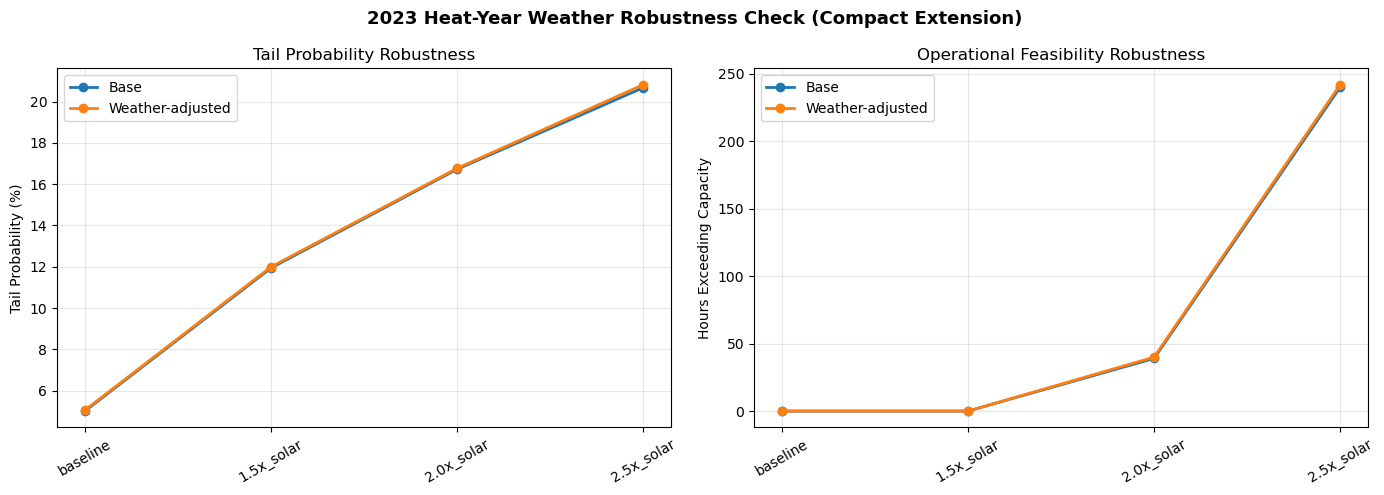

Saved: C:\Renewable-PowerGrid-Risk\data\processed\weather_robustness_2023_compact.csv
Saved: C:\Renewable-PowerGrid-Risk\figures\weather_robustness_compact_2023.png


In [15]:
# 7.2 Re-run core scenarios with weather-adjusted load and compare vs original

# Build a lookup for monthly-hour weather multipliers
weather_mult_lookup = temp_delta[['month', 'hour', 'load_mult_weather']].copy()

weather_robust_metrics = []

for scenario in scenarios:
    # --- Original scenario (no weather perturbation) ---
    s0 = df_2025.copy()
    s0['ERCOT.PVGR.GEN'] = s0['ERCOT.PVGR.GEN'] * scenario['solar_mult']
    s0['ERCOT.WIND.GEN'] = s0['ERCOT.WIND.GEN'] * scenario['wind_mult']
    s0['NET_LOAD'] = s0['ERCOT.LOAD'] - s0['ERCOT.PVGR.GEN'] - s0['ERCOT.WIND.GEN']
    s0['ramp_1h'] = s0['NET_LOAD'].diff()
    s0['ramp_3h'] = s0['NET_LOAD'].diff(3)

    risk0 = compute_risk_metrics(s0, fixed_threshold=6033)
    adq0 = assess_ramping_adequacy(s0, scenario['name'], TOTAL_RAMP_CAPACITY)

    sunset0 = s0[s0['hour'].isin(sunset_hours) & s0['month'].isin(summer_months)].copy()
    day0 = compute_daily_sunset_ramp(sunset0)

    # --- Weather-perturbed load scenario (2023 heat-year delta on 2025 profile) ---
    s1 = df_2025.copy()
    s1 = s1.merge(weather_mult_lookup, on=['month', 'hour'], how='left')
    s1['load_mult_weather'] = s1['load_mult_weather'].fillna(1.0)

    s1['ERCOT.LOAD'] = s1['ERCOT.LOAD'] * s1['load_mult_weather']
    s1['ERCOT.PVGR.GEN'] = s1['ERCOT.PVGR.GEN'] * scenario['solar_mult']
    s1['ERCOT.WIND.GEN'] = s1['ERCOT.WIND.GEN'] * scenario['wind_mult']
    s1['NET_LOAD'] = s1['ERCOT.LOAD'] - s1['ERCOT.PVGR.GEN'] - s1['ERCOT.WIND.GEN']
    s1['ramp_1h'] = s1['NET_LOAD'].diff()
    s1['ramp_3h'] = s1['NET_LOAD'].diff(3)

    risk1 = compute_risk_metrics(s1, fixed_threshold=6033)
    adq1 = assess_ramping_adequacy(s1, scenario['name'], TOTAL_RAMP_CAPACITY)

    sunset1 = s1[s1['hour'].isin(sunset_hours) & s1['month'].isin(summer_months)].copy()
    day1 = compute_daily_sunset_ramp(sunset1)

    weather_robust_metrics.append({
        'Scenario': scenario['name'],
        'Solar Mult': scenario['solar_mult'],
        'Tail Prob Base (%)': risk0['tail_probability'] * 100,
        'Tail Prob Weather (%)': risk1['tail_probability'] * 100,
        'P99 Base (MW)': risk0['p99_ramp_1h'],
        'P99 Weather (MW)': risk1['p99_ramp_1h'],
        'Max Sunset Base (MW)': day0['sunset_ramp_3h'].max(),
        'Max Sunset Weather (MW)': day1['sunset_ramp_3h'].max(),
        'Hours > Capacity Base': adq0['hours_exceeding_capacity'],
        'Hours > Capacity Weather': adq1['hours_exceeding_capacity'],
    })

weather_robust_df = pd.DataFrame(weather_robust_metrics)
weather_robust_df['Delta Tail Prob (pp)'] = weather_robust_df['Tail Prob Weather (%)'] - weather_robust_df['Tail Prob Base (%)']
weather_robust_df['Delta P99 (MW)'] = weather_robust_df['P99 Weather (MW)'] - weather_robust_df['P99 Base (MW)']
weather_robust_df['Delta Max Sunset (MW)'] = weather_robust_df['Max Sunset Weather (MW)'] - weather_robust_df['Max Sunset Base (MW)']
weather_robust_df['Delta Hours > Capacity'] = weather_robust_df['Hours > Capacity Weather'] - weather_robust_df['Hours > Capacity Base']

print('\n=== WEATHER ROBUSTNESS TABLE (2023 HEAT-YEAR LOAD PERTURBATION) ===')
display(weather_robust_df.round(2))

# One compact figure for paper main text
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(weather_robust_df))
labels = weather_robust_df['Scenario'].tolist()

axes[0].plot(x, weather_robust_df['Tail Prob Base (%)'], marker='o', linewidth=2, label='Base')
axes[0].plot(x, weather_robust_df['Tail Prob Weather (%)'], marker='o', linewidth=2, label='Weather-adjusted')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=30)
axes[0].set_title('Tail Probability Robustness')
axes[0].set_ylabel('Tail Probability (%)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(x, weather_robust_df['Hours > Capacity Base'], marker='o', linewidth=2, label='Base')
axes[1].plot(x, weather_robust_df['Hours > Capacity Weather'], marker='o', linewidth=2, label='Weather-adjusted')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30)
axes[1].set_title('Operational Feasibility Robustness')
axes[1].set_ylabel('Hours Exceeding Capacity')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('2023 Heat-Year Weather Robustness Check (Compact Extension)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_robustness_compact_2023.png', dpi=300, bbox_inches='tight')
plt.show()

# Optional: save table for manuscript integration
weather_robust_df.to_csv(PROCESSED_DIR / 'weather_robustness_2023_compact.csv', index=False)
print(f"Saved: {PROCESSED_DIR / 'weather_robustness_2023_compact.csv'}")
print(f"Saved: {FIGURES_DIR / 'weather_robustness_compact_2023.png'}")

## Findings Summary (2023 Heat-Year Weather Robustness)
The 2023 heat-year weather robustness check shows that the main conclusion of this study does not change when weather stress is added: increasing solar penetration remains the dominant driver of ramping risk. As solar scaling rises from baseline to 2.5x, tail probability increases sharply (about 5.01% to 20.67% in the base case), and hours exceeding ramping capacity rise from 0 to 240, indicating a major escalation in operational pressure. When weather-adjusted load is applied, the same pattern persists and becomes only slightly worse (for example, at 2.5x solar, tail probability increases from 20.67% to 20.82% and capacity exceedance hours from 240 to 242). In plain terms, extreme heat-like weather acts as an added stressor, but it does not create the risk pattern by itself; the primary source of the ramping burden is still high renewable-driven net-load transition, especially at higher solar penetration levels.

## 7.3 Multi-Year Normalization Robustness (2023-2025)

This test rescales each year to the 2025 system level so that interannual differences mainly reflect differences in load and renewable-output profiles rather than system size.

Normalization rules:
- Solar: scale by peak-generation ratio to the 2025 peak
- Wind: scale by peak-generation ratio to the 2025 peak
- Load: scale by mean-load ratio to the 2025 mean

The resulting comparison asks whether the renewable-scaling effect persists across three independently observed load and renewable-production years after the years are put on the same demand and capacity basis.

**Caveat (linear scaling limitation):** This normalization is a *first-order* level correction. It rescales the magnitude of each year's load and renewable output but applies the historical hourly *shape* unchanged. Because the 2023 solar fleet was less than half the 2025 fleet (peak ~13.7 GW vs ~29.5 GW) and geographically less diverse, scaling its output up by ~2.15× amplifies the relative variability of a smaller fleet — a real 29.5 GW fleet is spatially smoother than a scaled-up 13.7 GW one. Linear peak-scaling therefore removes the *size* of the system-growth difference but **not** the spatial-smoothing component of it. As a result, part of the higher normalized tail risk in earlier years should be read as a scaling artifact rather than purely profile-driven variability. The check is still informative as a like-for-like level comparison, but it is a bound, not an exact decomposition of weather vs. fleet-composition effects.

=== MULTI-YEAR NORMALIZATION TO 2025 LEVEL ===


,year,solar_mult_to_2025,wind_mult_to_2025,load_mult_to_2025
0,2023,2.147,1.076,1.106
1,2024,1.367,1.022,1.067
2,2025,1.000,1.000,1.000



Baseline 2025 fixed threshold (normalized): 6033.10 MW


,Year,Solar × to 2025,Wind × to 2025,Load × to 2025,Mean |1h Ramp| (MW),Std |1h Ramp| (MW),Tail Prob (%),Conditional Tail (MW),P99 1h Ramp (MW),Max Sunset Ramp 17→20h (MW),Hours > Capacity
0,2023,2.15,1.08,1.11,2560.63,2330.48,7.98,8356.50,11294.25,17655.23,0
1,2024,1.37,1.02,1.07,2342.09,2184.16,6.50,8380.50,10589.00,22842.65,0
2,2025,1.00,1.00,1.00,2172.47,2047.37,5.00,8432.59,10002.68,19420.61,0


Saved: C:\Renewable-PowerGrid-Risk\data\processed\multi_year_normalized_2023_2025.csv


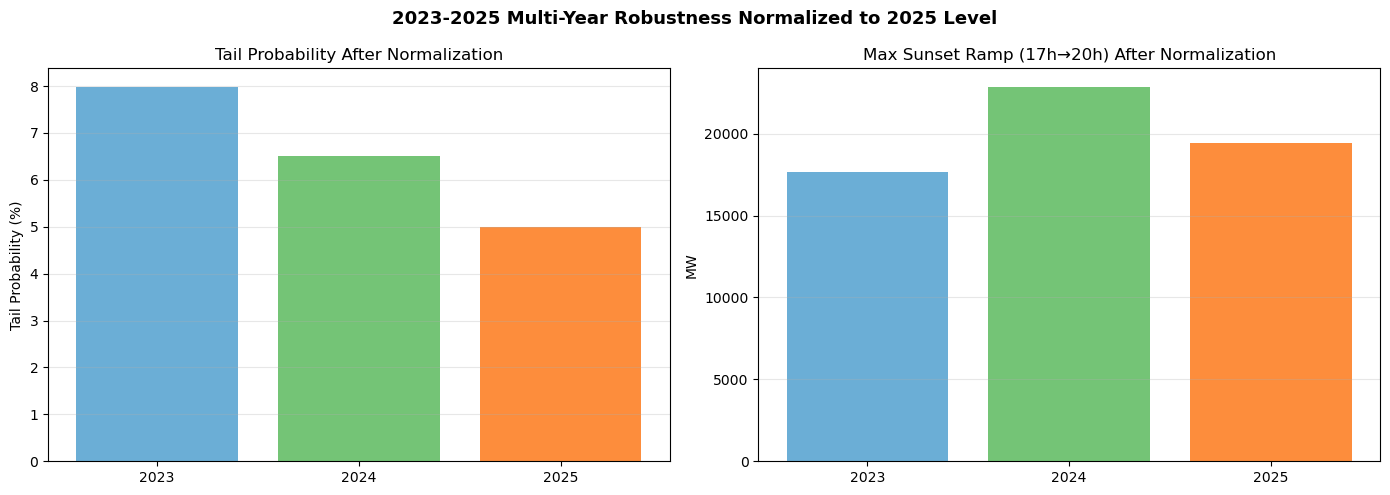

Saved: C:\Renewable-PowerGrid-Risk\figures\multi_year_normalization_robustness.png


In [16]:
# Normalize 2023 and 2024 to the 2025 load and capacity level
# The goal is to isolate weather/profile differences rather than system-size differences.

# Derive normalization multipliers directly from the data so they cannot drift
# out of sync if the merged dataset is regenerated.
#   Solar / Wind : peak-generation ratio to the 2025 peak
#   Load         : mean-load ratio to the 2025 mean
NORM_YEARS = [2023, 2024, 2025]
_norm_src = df[df['datetime'].dt.year.isin(NORM_YEARS)].copy()
_norm_src['year'] = _norm_src['datetime'].dt.year
_peak_solar = _norm_src.groupby('year')['ERCOT.PVGR.GEN'].max()
_peak_wind = _norm_src.groupby('year')['ERCOT.WIND.GEN'].max()
_mean_load = _norm_src.groupby('year')['ERCOT.LOAD'].mean()

year_normalization_lookup = pd.DataFrame([
    {
        'year': y,
        'solar_mult_to_2025': _peak_solar[2025] / _peak_solar[y],
        'wind_mult_to_2025': _peak_wind[2025] / _peak_wind[y],
        'load_mult_to_2025': _mean_load[2025] / _mean_load[y],
    }
    for y in NORM_YEARS
])

def normalize_year_to_2025(frame, load_mult, solar_mult, wind_mult):
    normalized = frame.sort_values('datetime').copy().reset_index(drop=True)
    normalized['ERCOT.LOAD'] = normalized['ERCOT.LOAD'] * load_mult
    normalized['ERCOT.PVGR.GEN'] = normalized['ERCOT.PVGR.GEN'] * solar_mult
    normalized['ERCOT.WIND.GEN'] = normalized['ERCOT.WIND.GEN'] * wind_mult
    normalized['NET_LOAD'] = normalized['ERCOT.LOAD'] - normalized['ERCOT.PVGR.GEN'] - normalized['ERCOT.WIND.GEN']
    normalized['month'] = pd.to_datetime(normalized['datetime']).dt.month
    normalized['hour'] = pd.to_datetime(normalized['datetime']).dt.hour
    normalized['ramp_1h'] = normalized['NET_LOAD'].diff()
    normalized['ramp_3h'] = normalized['NET_LOAD'].diff(3)
    return normalized

normalized_year_rows = []
normalized_year_frames = []

baseline_2025_normalized = None

for row in year_normalization_lookup.itertuples(index=False):
    year_df = df[df['datetime'].dt.year == row.year].copy()
    if year_df.empty:
        continue

    normalized = normalize_year_to_2025(
        year_df,
        load_mult=row.load_mult_to_2025,
        solar_mult=row.solar_mult_to_2025,
        wind_mult=row.wind_mult_to_2025,
    )
    normalized['year'] = row.year
    normalized_year_frames.append(normalized)

    if row.year == 2025:
        baseline_2025_normalized = normalized.copy()

if baseline_2025_normalized is None:
    raise ValueError('No 2025 rows found for baseline normalization.')

baseline_threshold = compute_risk_metrics(baseline_2025_normalized)['threshold_P95']

for normalized in normalized_year_frames:
    year = int(normalized['year'].iloc[0])
    risk = compute_risk_metrics(normalized, fixed_threshold=baseline_threshold)
    hours_exceeding_capacity = int((normalized['ramp_1h'].abs() > TOTAL_RAMP_CAPACITY).sum())

    # Use the same 17h->20h sunset ramp definition as the rest of the notebook
    # (compute_daily_sunset_ramp), restricted to the May-Sep summer window.
    sunset_frame = normalized[
        normalized['hour'].isin(sunset_hours) & normalized['month'].isin(summer_months)
    ].copy()
    daily_sunset_norm = compute_daily_sunset_ramp(sunset_frame)
    max_sunset_ramp = (
        float(daily_sunset_norm['sunset_ramp_3h'].max())
        if not daily_sunset_norm.empty else float('nan')
    )

    normalized_year_rows.append({
        'Year': year,
        'Solar × to 2025': float(year_normalization_lookup.loc[year_normalization_lookup['year'] == year, 'solar_mult_to_2025'].iloc[0]),
        'Wind × to 2025': float(year_normalization_lookup.loc[year_normalization_lookup['year'] == year, 'wind_mult_to_2025'].iloc[0]),
        'Load × to 2025': float(year_normalization_lookup.loc[year_normalization_lookup['year'] == year, 'load_mult_to_2025'].iloc[0]),
        'Mean |1h Ramp| (MW)': risk['mean_abs_ramp_1h'],
        'Std |1h Ramp| (MW)': risk['std_abs_ramp_1h'],
        'Tail Prob (%)': risk['tail_probability'] * 100,
        'Conditional Tail (MW)': risk['conditional_tail'],
        'P99 1h Ramp (MW)': risk['p99_ramp_1h'],
        'Max Sunset Ramp 17→20h (MW)': max_sunset_ramp,
        'Hours > Capacity': hours_exceeding_capacity,
    })

normalized_year_df = pd.DataFrame(normalized_year_rows).sort_values('Year').reset_index(drop=True)

print('=== MULTI-YEAR NORMALIZATION TO 2025 LEVEL ===')
display(year_normalization_lookup.round(3))
print()
print(f'Baseline 2025 fixed threshold (normalized): {baseline_threshold:.2f} MW')
display(normalized_year_df.round(2))

normalized_year_df.to_csv(PROCESSED_DIR / 'multi_year_normalized_2023_2025.csv', index=False)
print(f"Saved: {PROCESSED_DIR / 'multi_year_normalized_2023_2025.csv'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(normalized_year_df['Year'].astype(str), normalized_year_df['Tail Prob (%)'], color=['#6baed6', '#74c476', '#fd8d3c'])
axes[0].set_title('Tail Probability After Normalization')
axes[0].set_ylabel('Tail Probability (%)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(normalized_year_df['Year'].astype(str), normalized_year_df['Max Sunset Ramp 17→20h (MW)'], color=['#6baed6', '#74c476', '#fd8d3c'])
axes[1].set_title('Max Sunset Ramp (17h→20h) After Normalization')
axes[1].set_ylabel('MW')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('2023-2025 Multi-Year Robustness Normalized to 2025 Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'multi_year_normalization_robustness.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'multi_year_normalization_robustness.png'}")



=== MULTI-YEAR SOLAR SCALING SWEEP (2025-NORMALIZED) ===

Tail Probability (%)


Year,2023,2024,2025
Solar Label,,,
1.0x,7.98,6.50,5.00
1.5x,14.26,12.12,11.94
2.0x,18.78,16.74,16.72
2.5x,22.54,20.38,20.67



Sunset Ramp Volatility (MW)


Year,2023,2024,2025
Solar Label,,,
1.0x,3521.15,4206.32,3883.99
1.5x,6104.99,6775.16,6467.76
2.0x,8944.87,9582.38,9255.60
2.5x,11881.23,12460.32,12112.98



Flexibility Exceedance Hours


Year,2023,2024,2025
Solar Label,,,
1.0x,0,0,0
1.5x,12,0,0
2.0x,83,65,39
2.5x,295,252,240



P99 1h Ramp (MW)


Year,2023,2024,2025
Solar Label,,,
1.0x,11294.25,10589.00,10002.68
1.5x,16951.63,16515.31,15508.60
2.0x,22898.40,22466.00,21162.70
2.5x,29116.20,28651.69,27037.20


Saved: C:\Renewable-PowerGrid-Risk\data\processed\multi_year_solar_scaling_sweep.csv


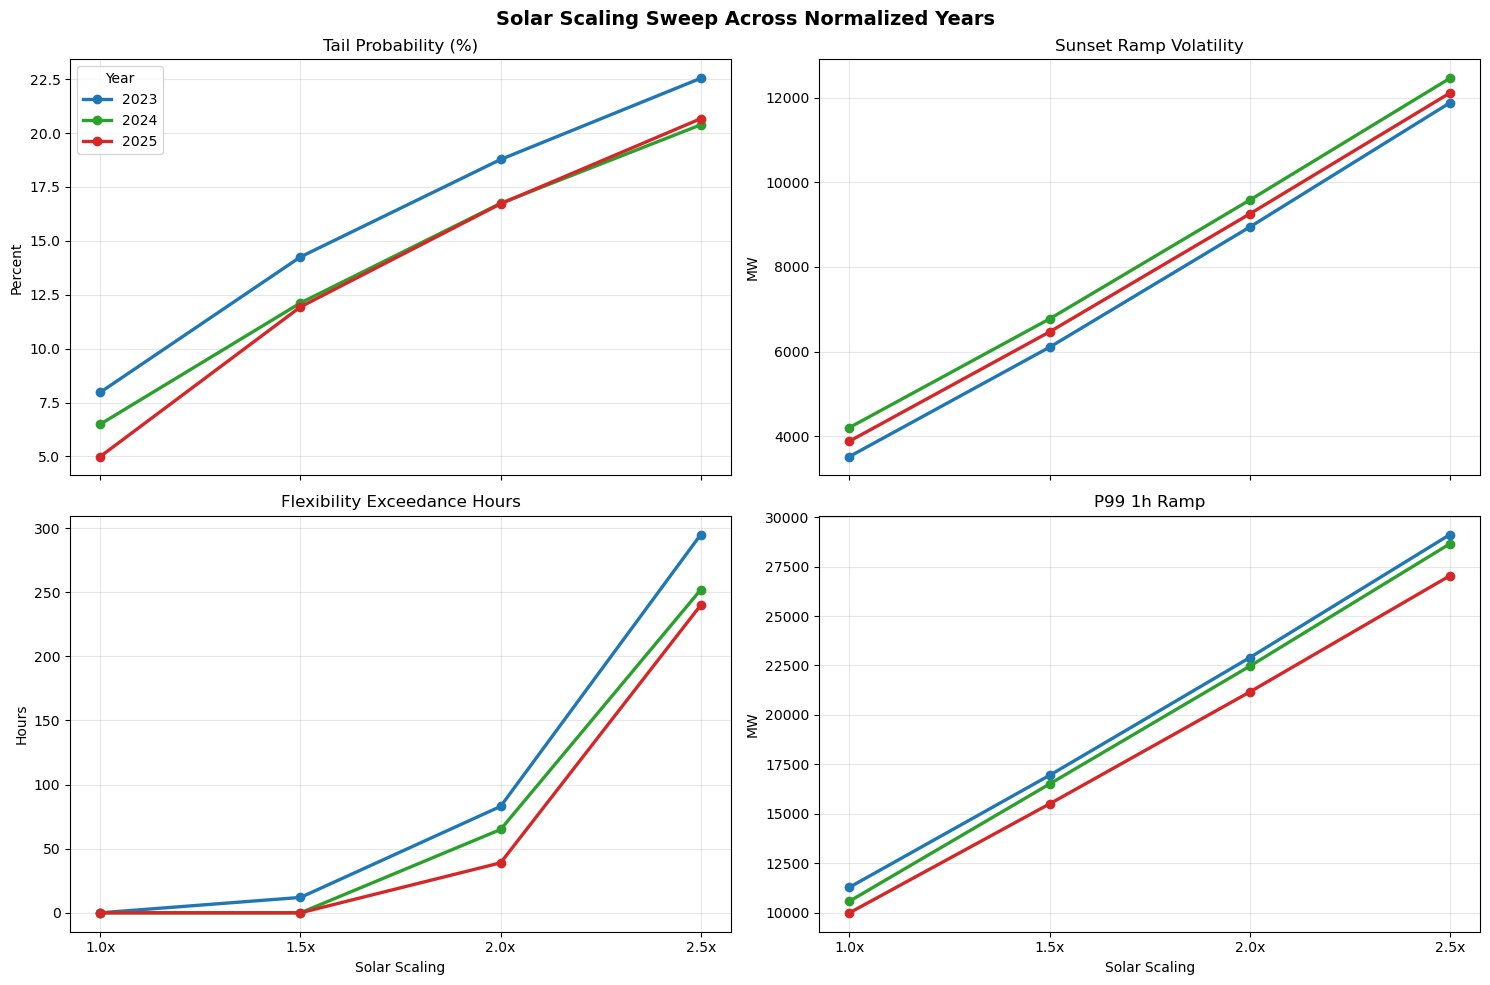

Saved: C:\Renewable-PowerGrid-Risk\figures\multi_year_solar_scaling_sweep.png


In [17]:
# 7.4 Multi-year solar scaling sweep on 2025-normalized years
# This keeps demand and capacity on a common basis and varies only solar output.

solar_scalings = [1.0, 1.5, 2.0, 2.5]
year_colors = {
    2023: '#1f77b4',
    2024: '#2ca02c',
    2025: '#d62728',
}

solar_sweep_rows = []

for normalized_year in normalized_year_frames:
    year = int(normalized_year['year'].iloc[0])
    base_year = normalized_year.copy()
    base_year['month'] = pd.to_datetime(base_year['datetime']).dt.month
    base_year['hour'] = pd.to_datetime(base_year['datetime']).dt.hour

    for solar_scale in solar_scalings:
        scenario_df = base_year.copy()
        scenario_df['ERCOT.PVGR.GEN'] = scenario_df['ERCOT.PVGR.GEN'] * solar_scale
        scenario_df['NET_LOAD'] = scenario_df['ERCOT.LOAD'] - scenario_df['ERCOT.PVGR.GEN'] - scenario_df['ERCOT.WIND.GEN']
        scenario_df['ramp_1h'] = scenario_df['NET_LOAD'].diff()
        scenario_df['ramp_3h'] = scenario_df['NET_LOAD'].diff(3)

        risk = compute_risk_metrics(scenario_df, fixed_threshold=baseline_threshold)
        sunset_mask = scenario_df['hour'].isin(sunset_hours) & scenario_df['month'].isin(summer_months)
        sunset_ramp = scenario_df.loc[sunset_mask, 'ramp_3h'].abs()
        flex_exceed_hours = int((scenario_df['ramp_1h'].abs() > TOTAL_RAMP_CAPACITY).sum())

        solar_sweep_rows.append({
            'Year': year,
            'Solar Scaling': solar_scale,
            'Tail Probability (%)': risk['tail_probability'] * 100,
            'Sunset Ramp Volatility (MW)': sunset_ramp.std(ddof=0),
            'Flexibility Exceedance Hours': flex_exceed_hours,
            'P99 1h Ramp (MW)': risk['p99_ramp_1h'],
        })

solar_sweep_df = pd.DataFrame(solar_sweep_rows)
solar_sweep_df['Solar Label'] = solar_sweep_df['Solar Scaling'].map(lambda x: f'{x:.1f}x')

print('\n=== MULTI-YEAR SOLAR SCALING SWEEP (2025-NORMALIZED) ===')

table_metrics = [
    ('Tail Probability (%)', 'Tail Probability (%)'),
    ('Sunset Ramp Volatility (MW)', 'Sunset Ramp Volatility (MW)'),
    ('Flexibility Exceedance Hours', 'Flexibility Exceedance Hours'),
    ('P99 1h Ramp (MW)', 'P99 1h Ramp (MW)'),
]

for metric_name, metric_label in table_metrics:
    wide_table = (
        solar_sweep_df.pivot(index='Solar Label', columns='Year', values=metric_name)
        .reindex([f'{x:.1f}x' for x in solar_scalings])
        .rename(columns={2023: '2023', 2024: '2024', 2025: '2025'})
    )
    print(f'\n{metric_label}')
    display(wide_table.round(2))

solar_sweep_df.to_csv(PROCESSED_DIR / 'multi_year_solar_scaling_sweep.csv', index=False)
print(f"Saved: {PROCESSED_DIR / 'multi_year_solar_scaling_sweep.csv'}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
metric_specs = [
    ('Tail Probability (%)', 'Tail Probability (%)', 'Percent'),
    ('Sunset Ramp Volatility (MW)', 'Sunset Ramp Volatility', 'MW'),
    ('Flexibility Exceedance Hours', 'Flexibility Exceedance Hours', 'Hours'),
    ('P99 1h Ramp (MW)', 'P99 1h Ramp', 'MW'),
]

for ax, (metric_name, title, ylabel) in zip(axes.flatten(), metric_specs):
    for year in [2023, 2024, 2025]:
        sub = solar_sweep_df[solar_sweep_df['Year'] == year].sort_values('Solar Scaling')
        ax.plot(
            sub['Solar Scaling'],
            sub[metric_name],
            marker='o',
            linewidth=2.4,
            color=year_colors[year],
            label=str(year),
        )
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.set_xticks(solar_scalings)
    ax.set_xticklabels([f'{x:.1f}x' for x in solar_scalings])

axes[0, 0].legend(title='Year')
for ax in axes[1, :]:
    ax.set_xlabel('Solar Scaling')

plt.suptitle('Solar Scaling Sweep Across Normalized Years', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'multi_year_solar_scaling_sweep.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'multi_year_solar_scaling_sweep.png'}")

## Findings Summary (Multi-Year Normalization)
After normalizing 2023 and 2024 load, solar, and wind to the 2025 level (against a common fixed threshold of ~6,033 MW), the renewable-scaling effect remains visible across all three independently observed load and renewable-production years. Tail probability declines monotonically from the earliest to the most recent normalized year — 2023: 7.98%, 2024: 6.50%, 2025: 5.00% — and the mean absolute 1-hour ramp follows the same ordering (2023: ~2,561 MW, 2024: ~2,342 MW, 2025: ~2,172 MW). The 17h→20h maximum sunset ramp stays in the ~17.7–22.8 GW band across years (2023: ~17,655 MW, 2024: ~22,843 MW, 2025: ~19,421 MW), and no year exceeds dispatchable ramp capacity at baseline (1.0× solar), consistent with the scenario results above.

Critically, the solar scaling sweep (§7.4) shows that the *slope* of the scaling effect is nearly identical across years: all three exhibit a ~15–17 pp tail-probability jump from 1.0× to 2.5× solar, while the interannual spread at any given scaling level is only 2–3 pp. The renewable-scaling signal is therefore 5–7× larger than the year-to-year variation, confirming that the effect is robust across independently observed load and renewable-output profiles — not an artifact of the 2025 system alone.

Given the linear-scaling caveat noted above, the remaining interannual spread (~2–3 pp) reflects a mixture of genuine profile variability and fleet-composition artifact (the amplified relative variability of smaller, less diverse earlier fleets). It should be read as an upper bound on the year-to-year effect rather than a clean weather-only decomposition.

## 8. Weather-Effect Strength Sweep (Compact Dominance Test)

This sweep scales only the weather-load perturbation strength while keeping the renewable scenarios unchanged.

Goal:
- Quantify how large weather-load sensitivity must become before it materially changes ramp-risk conclusions.
- Show whether solar scaling remains the dominant driver across plausible weather-effect strengths.


=== WEATHER-EFFECT SENSITIVITY SWEEP ===


,Scenario,Weather Strength,Tail Probability (%),P99 1h Ramp (MW),Max Sunset Ramp (MW),Hours Exceeding Capacity,Delta Tail Prob (pp),Delta P99 (MW),Delta Max Sunset (MW),Delta Hours > Capacity
0,baseline,0.0,5.01,10002.68,19420.61,0,0.00,0.00,0.0,0
1,baseline,0.5,5.04,10008.42,19420.61,0,0.03,5.74,0.0,0
2,baseline,1.0,5.06,10011.33,19420.61,0,0.05,8.65,0.0,0
3,baseline,2.0,5.20,10032.46,19420.61,0,0.19,29.78,0.0,0
4,baseline,3.0,5.43,10094.02,19420.61,0,0.42,91.34,0.0,0
5,2.5x_solar,0.0,20.67,27037.20,57544.88,240,0.00,0.00,0.0,0
6,2.5x_solar,0.5,20.77,27067.04,57544.88,242,0.10,29.84,0.0,2
7,2.5x_solar,1.0,20.82,27067.04,57544.88,242,0.15,29.84,0.0,2
8,2.5x_solar,2.0,21.06,27113.96,57544.88,245,0.39,76.76,0.0,5
9,2.5x_solar,3.0,21.34,27124.46,57544.88,247,0.67,87.26,0.0,7



=== DOMINANCE CHECK (2.5x solar scenario) ===
Solar-driven tail-probability jump (baseline -> 2.5x solar): 15.66 percentage points
Solar-driven capacity-hours jump (baseline -> 2.5x solar): 240 hours


,Weather Strength,Delta Tail Prob (pp),Tail Delta as % of Solar Jump,Delta Hours > Capacity,Capacity-Hours Delta as % of Solar Jump
5,0.0,0.00,0.00,0,0.00
6,0.5,0.10,0.66,2,0.83
7,1.0,0.15,0.95,2,0.83
8,2.0,0.39,2.48,5,2.08
9,3.0,0.67,4.30,7,2.92


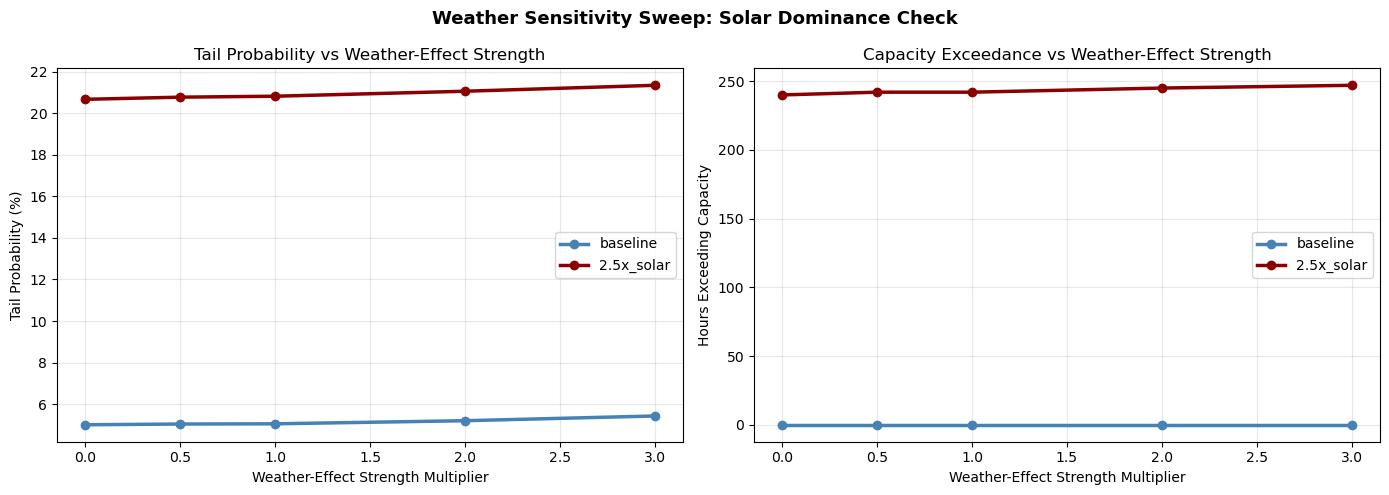

Saved: C:\Renewable-PowerGrid-Risk\data\processed\weather_strength_sweep_dominance.csv
Saved: C:\Renewable-PowerGrid-Risk\figures\weather_strength_sweep_dominance.png


In [18]:
# 8.1 Weather-effect sensitivity sweep
# strength = 0.0 means no weather perturbation
# strength = 1.0 uses the current calibrated weather perturbation
# higher strengths test when weather impact starts competing with solar scaling impact

weather_strengths = [0.0, 0.5, 1.0, 2.0, 3.0]
focus_scenarios = ['baseline', '2.5x_solar']

sweep_rows = []

for sname in focus_scenarios:
    sc = next(s for s in scenarios if s['name'] == sname)

    for strength in weather_strengths:
        d = df_2025.copy()
        d = d.merge(weather_mult_lookup, on=['month', 'hour'], how='left')
        d['load_mult_weather'] = d['load_mult_weather'].fillna(1.0)

        # Scale weather effect around 1.0 so strength=0 leaves load unchanged.
        d['load_mult_scaled'] = 1.0 + strength * (d['load_mult_weather'] - 1.0)
        d['load_mult_scaled'] = d['load_mult_scaled'].clip(0.80, 1.30)

        # Apply load and renewable scenario multipliers
        d['ERCOT.LOAD'] = d['ERCOT.LOAD'] * d['load_mult_scaled']
        d['ERCOT.PVGR.GEN'] = d['ERCOT.PVGR.GEN'] * sc['solar_mult']
        d['ERCOT.WIND.GEN'] = d['ERCOT.WIND.GEN'] * sc['wind_mult']
        d['NET_LOAD'] = d['ERCOT.LOAD'] - d['ERCOT.PVGR.GEN'] - d['ERCOT.WIND.GEN']
        d['ramp_1h'] = d['NET_LOAD'].diff()
        d['ramp_3h'] = d['NET_LOAD'].diff(3)

        rk = compute_risk_metrics(d, fixed_threshold=6033)
        adq = assess_ramping_adequacy(d, sname, TOTAL_RAMP_CAPACITY)
        ds = compute_daily_sunset_ramp(d[d['hour'].isin(sunset_hours) & d['month'].isin(summer_months)].copy())

        sweep_rows.append({
            'Scenario': sname,
            'Weather Strength': strength,
            'Tail Probability (%)': rk['tail_probability'] * 100,
            'P99 1h Ramp (MW)': rk['p99_ramp_1h'],
            'Max Sunset Ramp (MW)': ds['sunset_ramp_3h'].max(),
            'Hours Exceeding Capacity': adq['hours_exceeding_capacity'],
        })

weather_sweep_df = pd.DataFrame(sweep_rows)

# Deltas relative to strength=0 for each scenario
base_by_scenario = (
    weather_sweep_df[weather_sweep_df['Weather Strength'] == 0.0]
    .set_index('Scenario')
)

weather_sweep_df['Delta Tail Prob (pp)'] = weather_sweep_df.apply(
    lambda r: r['Tail Probability (%)'] - base_by_scenario.loc[r['Scenario'], 'Tail Probability (%)'], axis=1
)
weather_sweep_df['Delta P99 (MW)'] = weather_sweep_df.apply(
    lambda r: r['P99 1h Ramp (MW)'] - base_by_scenario.loc[r['Scenario'], 'P99 1h Ramp (MW)'], axis=1
)
weather_sweep_df['Delta Max Sunset (MW)'] = weather_sweep_df.apply(
    lambda r: r['Max Sunset Ramp (MW)'] - base_by_scenario.loc[r['Scenario'], 'Max Sunset Ramp (MW)'], axis=1
)
weather_sweep_df['Delta Hours > Capacity'] = weather_sweep_df.apply(
    lambda r: r['Hours Exceeding Capacity'] - base_by_scenario.loc[r['Scenario'], 'Hours Exceeding Capacity'], axis=1
)

print('\n=== WEATHER-EFFECT SENSITIVITY SWEEP ===')
display(weather_sweep_df.round(2))

# Compare weather-effect deltas at 2.5x solar to the solar-effect jump itself
base_tail = summary_df.loc[summary_df['Scenario'] == 'baseline', 'Tail Probability (%)'].iloc[0]
high_tail = summary_df.loc[summary_df['Scenario'] == '2.5x_solar', 'Tail Probability (%)'].iloc[0]
solar_jump_tail_pp = high_tail - base_tail

base_hours = summary_df.loc[summary_df['Scenario'] == 'baseline', 'Hours Exceeding Capacity'].iloc[0]
high_hours = summary_df.loc[summary_df['Scenario'] == '2.5x_solar', 'Hours Exceeding Capacity'].iloc[0]
solar_jump_hours = high_hours - base_hours

high_rows = weather_sweep_df[weather_sweep_df['Scenario'] == '2.5x_solar'].copy()
high_rows['Tail Delta as % of Solar Jump'] = np.where(
    solar_jump_tail_pp != 0,
    100 * high_rows['Delta Tail Prob (pp)'] / solar_jump_tail_pp,
    np.nan,
)
high_rows['Capacity-Hours Delta as % of Solar Jump'] = np.where(
    solar_jump_hours != 0,
    100 * high_rows['Delta Hours > Capacity'] / solar_jump_hours,
    np.nan,
)

print('\n=== DOMINANCE CHECK (2.5x solar scenario) ===')
print(f'Solar-driven tail-probability jump (baseline -> 2.5x solar): {solar_jump_tail_pp:.2f} percentage points')
print(f'Solar-driven capacity-hours jump (baseline -> 2.5x solar): {solar_jump_hours:.0f} hours')
display(high_rows[[
    'Weather Strength',
    'Delta Tail Prob (pp)',
    'Tail Delta as % of Solar Jump',
    'Delta Hours > Capacity',
    'Capacity-Hours Delta as % of Solar Jump',
]].round(2))

# Compact figure for manuscript appendix or main text
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for sname, color in [('baseline', 'steelblue'), ('2.5x_solar', 'darkred')]:
    sub = weather_sweep_df[weather_sweep_df['Scenario'] == sname]
    axes[0].plot(sub['Weather Strength'], sub['Tail Probability (%)'], marker='o', linewidth=2.5, color=color, label=sname)
    axes[1].plot(sub['Weather Strength'], sub['Hours Exceeding Capacity'], marker='o', linewidth=2.5, color=color, label=sname)

axes[0].set_title('Tail Probability vs Weather-Effect Strength')
axes[0].set_xlabel('Weather-Effect Strength Multiplier')
axes[0].set_ylabel('Tail Probability (%)')
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].set_title('Capacity Exceedance vs Weather-Effect Strength')
axes[1].set_xlabel('Weather-Effect Strength Multiplier')
axes[1].set_ylabel('Hours Exceeding Capacity')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle('Weather Sensitivity Sweep: Solar Dominance Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'weather_strength_sweep_dominance.png', dpi=300, bbox_inches='tight')
plt.show()

weather_sweep_df.to_csv(PROCESSED_DIR / 'weather_strength_sweep_dominance.csv', index=False)
print(f"Saved: {PROCESSED_DIR / 'weather_strength_sweep_dominance.csv'}")
print(f"Saved: {FIGURES_DIR / 'weather_strength_sweep_dominance.png'}")

## Findings Summary (Weather Strength Sweep)
The weather-strength sweep shows that the main ramping-risk conclusion is robust: increasing solar penetration is the dominant driver of stress, while weather perturbations act as a smaller secondary amplifier. In the baseline case, tail probability changes only from about 5.01% to 5.43% as weather strength increases from 0 to 3, and hours exceeding ramp capacity remain at zero. In contrast, the 2.5x solar case starts at a much higher risk level (about 20.67% tail probability and 240 hours exceeding capacity) and rises further with stronger weather stress (to about 21.34% and 247 hours).
For interpretation in the JEI Results section, the key point is that weather effects matter, but they do not overturn the core result: high solar scaling creates most of the ramping burden, and weather mainly adds incremental stress on top of that baseline. The dominance check supports this conclusion quantitatively: even at the strongest tested weather perturbation, the additional tail-risk increase is only about 4.30% of the solar-driven jump, and the extra capacity-exceedance hours are about 2.92% of the solar-driven increase. This means reliability planning should prioritize flexibility solutions for renewable-driven sunset ramps first, then layer weather resilience as a complementary safeguard.